In [4]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from scipy.fft import fft2, fftshift, ifft2, ifftshift
from cv2 import dft, idft

In [50]:
img1 = cv2.imread('img1.jpg', cv2.IMREAD_GRAYSCALE)

In [4]:
cv2.imshow('image' , img1)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
def create_filter_mask(rows, cols, center_row, center_col, filter_type, cutoff_freq, cutoff_freq2=None):
    mask = np.ones((rows, cols), np.float32)
    
    if filter_type == 'lowpass':
        for i in range(rows):
            for j in range(cols):
                distance = np.sqrt((i - center_row)**2 + (j - center_col)**2)
                if distance > cutoff_freq:
                    mask[i, j] = 0
                    
    elif filter_type == 'highpass':
        for i in range(rows):
            for j in range(cols):
                distance = np.sqrt((i - center_row)**2 + (j - center_col)**2)
                if distance < cutoff_freq:
                    mask[i, j] = 0
                    
    elif filter_type == 'bandpass':
        inner_cutoff = cutoff_freq - 10
        outer_cutoff = cutoff_freq + 10
        for i in range(rows):
            for j in range(cols):
                distance = np.sqrt((i - center_row)**2 + (j - center_col)**2)
                if distance < inner_cutoff or distance > outer_cutoff:
                    mask[i, j] = 0
                    
    elif filter_type == 'bandstop':
        inner_cutoff = cutoff_freq - 10
        outer_cutoff = cutoff_freq + 10
        for i in range(rows):
            for j in range(cols):
                distance = np.sqrt((i - center_row)**2 + (j - center_col)**2)
                if inner_cutoff <= distance <= outer_cutoff:
                    mask[i, j] = 0
    
    elif filter_type == 'laplacian':
        inner_cutoff = cutoff_freq - 10
        outer_cutoff = cutoff_freq + 10
        crow, ccol = rows // 2, cols // 2
        u = np.arange(rows).reshape(-1, 1) - crow
        v = np.arange(cols).reshape(1, -1) - ccol
        D2 = u**2 + v**2
        mask = -4 * np.pi**2 * D2
    
    
    elif filter_type == 'gaussian_lowpass':
        for i in range(rows):
            for j in range(cols):
                distance = np.sqrt((i - center_row)**2 + (j - center_col)**2)
                mask[i, j] = np.exp(-(distance**2) / (2 * (cutoff_freq**2)))
                
    elif filter_type == 'gaussian_highpass':
        for i in range(rows):
            for j in range(cols):
                distance = np.sqrt((i - center_row)**2 + (j - center_col)**2)
                mask[i, j] = 1 - np.exp(-(distance**2) / (2 * (cutoff_freq**2)))
    
    elif filter_type == 'butterworth_lowpass':
        n = 2  
        for i in range(rows):
            for j in range(cols):
                distance = np.sqrt((i - center_row)**2 + (j - center_col)**2)
                if distance == 0:
                    mask[i, j] = 1
                else:
                    mask[i, j] = 1 / (1 + (distance / cutoff_freq)**(2*n))
    
    elif filter_type == 'butterworth_highpass':
        n = 2  
        for i in range(rows):
            for j in range(cols):
                distance = np.sqrt((i - center_row)**2 + (j - center_col)**2)
                if distance == 0:
                    mask[i, j] = 0
                else:
                    mask[i, j] = 1 / (1 + (cutoff_freq / distance)**(2*n))
    
    elif filter_type == 'notch':
        for i in range(rows):
            for j in range(cols):
                distance1 = np.sqrt((i - center_row)**2 + (j - center_col)**2)
                distance2 = np.sqrt((i - (rows - center_row))**2 + (j - (cols - center_col))**2)
                if distance1 < cutoff_freq or distance2 < cutoff_freq:
                    mask[i, j] = 0
    
    
    elif filter_type == 'homomorphic':
        gamma_l = 0.5  
        gamma_h = 2.0  
        c = 1  
        for i in range(rows):
            for j in range(cols):
                distance = np.sqrt((i - center_row)**2 + (j - center_col)**2)
                mask[i, j] = (gamma_h - gamma_l) * (1 - np.exp(-c * (distance**2) / (cutoff_freq**2))) + gamma_l
                    
    return mask

In [52]:
def apply_dft_and_filters(img, filter_type, cutoff_freq):
    img_float = img.astype(np.float32)
    dft = cv2.dft(img_float, flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shifted = np.fft.fftshift(dft)
    magnitude = cv2.magnitude(dft_shifted[:,:,0], dft_shifted[:,:,1])
    magnitude_log = np.log(1 + magnitude)
    rows, cols = img_float.shape
    crow, ccol = rows // 2, cols // 2
    mask = create_filter_mask(rows, cols, crow, ccol, filter_type, cutoff_freq)
    filtered_dft_real = dft_shifted[:,:,0] * mask
    filtered_dft_imag = dft_shifted[:,:,1] * mask
    filtered_dft = np.stack([filtered_dft_real, filtered_dft_imag], axis=2)
    filtered_magnitude = cv2.magnitude(filtered_dft_real, filtered_dft_imag)
    filtered_magnitude_log = np.log(1 + filtered_magnitude)
    reconstructed_dft = np.fft.ifftshift(filtered_dft)
    reconstructed_image = cv2.idft(reconstructed_dft, flags=cv2.DFT_SCALE | cv2.DFT_REAL_OUTPUT)
    reconstructed_image = np.abs(reconstructed_image)
    
    return {
        'original': img_float,
        'dft_shifted': dft_shifted,
        'magnitude': magnitude,
        'magnitude_log': magnitude_log,
        'filtered_dft': filtered_dft,
        'filtered_magnitude': filtered_magnitude,
        'filtered_magnitude_log': filtered_magnitude_log,
        'reconstructed': reconstructed_image,
        'mask': mask
    }

In [53]:
def apply_dft_and_filters_on_phase(img, filter_type, cutoff_freq):
    img_float = img.astype(np.float32)
    dft = fft2(img_float)
    dft_shifted = np.fft.fftshift(dft)
    magnitude = np.abs(dft_shifted)
    phase = np.angle(dft_shifted)
    rows, cols = img_float.shape
    crow, ccol = rows // 2, cols // 2
    mask = create_filter_mask(rows, cols, crow, ccol, filter_type, cutoff_freq)
    filtered_phase = phase * mask  
    filtered_dft = magnitude * np.exp(1j * filtered_phase)
    reconstructed_dft = np.fft.ifftshift(filtered_dft)
    reconstructed_image = ifft2(reconstructed_dft)
    reconstructed_image = np.real(reconstructed_image) 
    
    return {
        'original': img_float,
        'dft_shifted': dft_shifted,
        'phase': phase,
        'filtered_phase': filtered_phase,
        'reconstructed': reconstructed_image,
        'mask': mask
    }

In [43]:
results_lowpass_phase = apply_dft_and_filters_on_phase(img1 , 'gaussian_lowpass' , 200)
results_lowpass = apply_dft_and_filters(img1 , 'gaussian_lowpass' , 100)

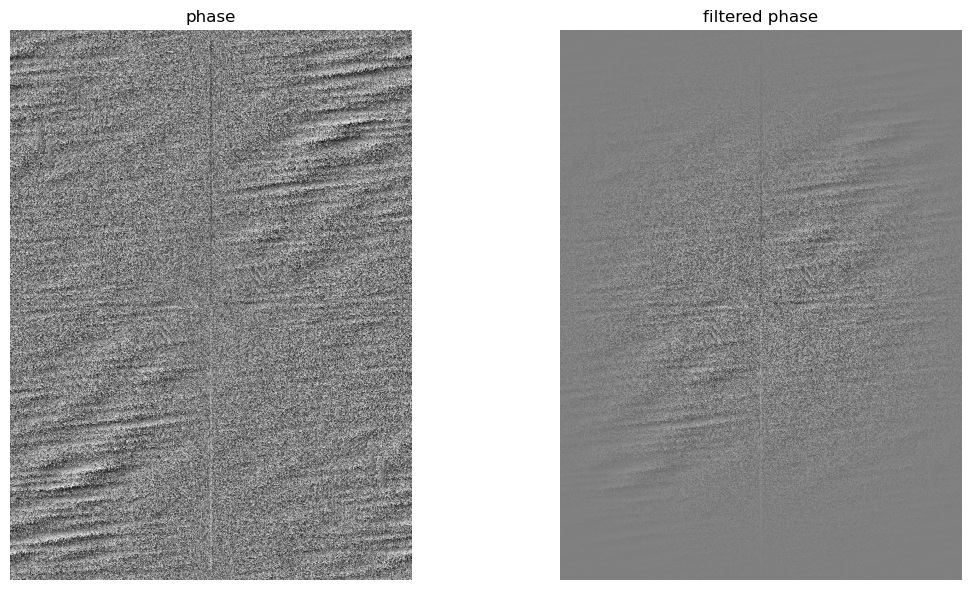

In [44]:
plt.figure(figsize=(12, 6))
plt.subplot(1 , 2, 1)
plt.imshow(results_lowpass_phase['phase'] , cmap='gray')
plt.title('phase')
plt.axis('off') 

plt.subplot(1 , 2 , 2)
plt.imshow(results_lowpass_phase['filtered_phase'] , cmap='gray')
plt.title('filtered phase')
plt.axis('off') 

plt.tight_layout()
plt.show()

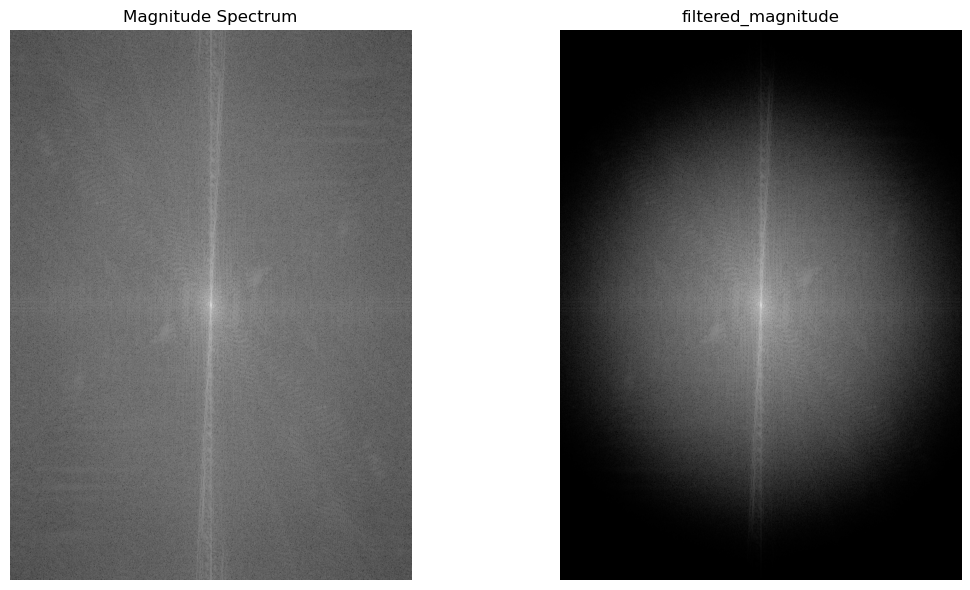

In [45]:
plt.figure(figsize=(12, 6))
plt.subplot(1 , 2, 1)
plt.imshow(results_lowpass['magnitude_log'] , cmap='gray')
plt.title('Magnitude Spectrum')
plt.axis('off') 

plt.subplot(1 , 2 , 2)
plt.imshow(results_lowpass['filtered_magnitude_log'] , cmap='gray')
plt.title('filtered_magnitude')
plt.axis('off') 

plt.tight_layout()
plt.show()

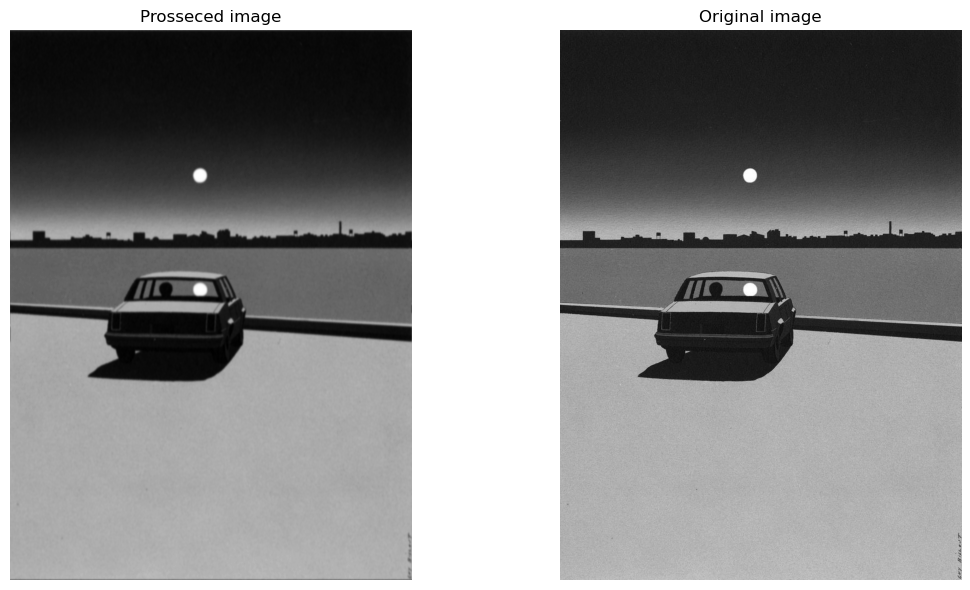

In [46]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(results_lowpass['reconstructed'] ,  cmap='gray')
plt.title('Prosseced image' )
plt.axis('off') 

plt.subplot(1, 2, 2)
plt.imshow(img1 , cmap='gray')
plt.title('Original image')
plt.axis('off') 

plt.tight_layout()
plt.show()

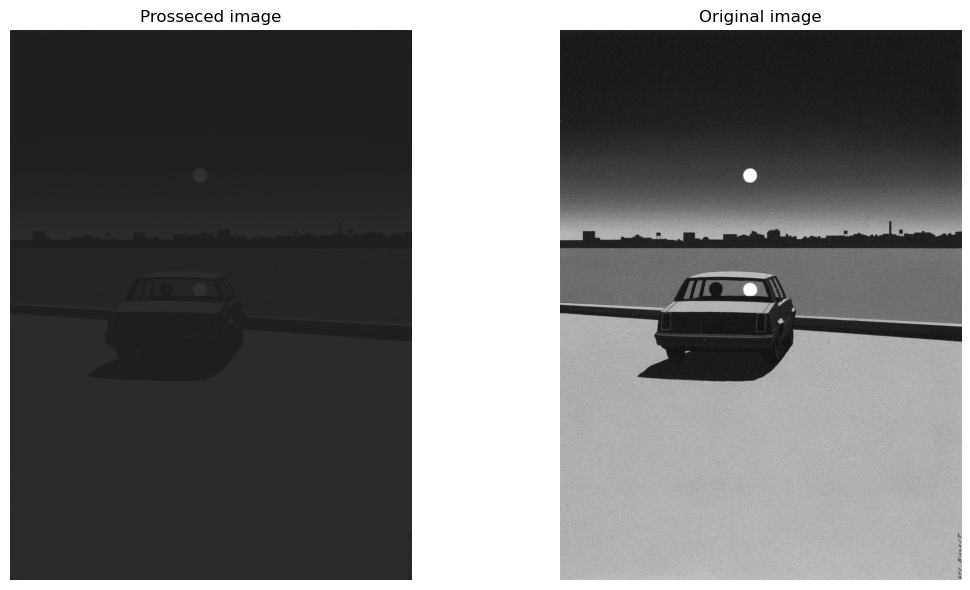

In [47]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(results_lowpass_phase['reconstructed'] ,  cmap='gray')
plt.title('Prosseced image' )
plt.axis('off') 

plt.subplot(1, 2, 2)
plt.imshow(img1 , cmap='gray')
plt.title('Original image')
plt.axis('off') 

plt.tight_layout()
plt.show()

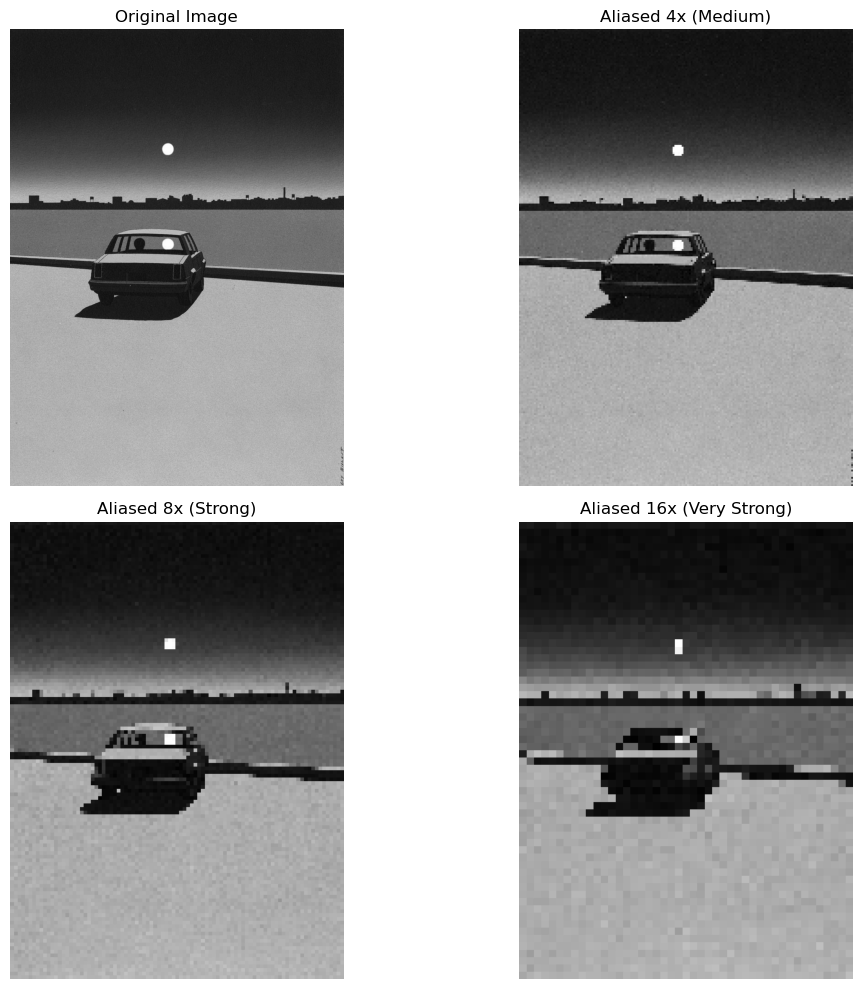

In [8]:
def apply_aliasing_effect(original, downscale_factor=4, method='nearest'):
    
    h, w = original.shape[:2]
    new_w = w // downscale_factor
    new_h = h // downscale_factor
    downsampled = cv2.resize(original, (new_w, new_h),    interpolation=cv2.INTER_NEAREST)
    if method == 'nearest':
        aliased = cv2.resize(downsampled, (w, h), interpolation=cv2.INTER_NEAREST)
    elif method == 'linear':
        aliased = cv2.resize(downsampled, (w, h), interpolation=cv2.INTER_LINEAR)
    elif method == 'cubic':
        aliased = cv2.resize(downsampled, (w, h), interpolation=cv2.INTER_CUBIC)
    else:
        aliased = cv2.resize(downsampled, (w, h), interpolation=cv2.INTER_NEAREST)
    
    return original, aliased, downsampled

def demo_aliasing():
   
    original, aliased_4x, _ = apply_aliasing_effect(img1, downscale_factor=4)
    _, aliased_8x, _ = apply_aliasing_effect(img1, downscale_factor=8)
    _, aliased_16x, _ = apply_aliasing_effect(img1, downscale_factor=16)

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    axes[0, 0].imshow(original , cmap = 'grey')
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(aliased_4x , cmap = 'grey')
    axes[0, 1].set_title('Aliased 4x (Medium)')
    axes[0, 1].axis('off')
    
    axes[1, 0].imshow(aliased_8x , cmap = 'grey')
    axes[1, 0].set_title('Aliased 8x (Strong)')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(aliased_16x , cmap = 'grey')
    axes[1, 1].set_title('Aliased 16x (Very Strong)')
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

demo_aliasing()

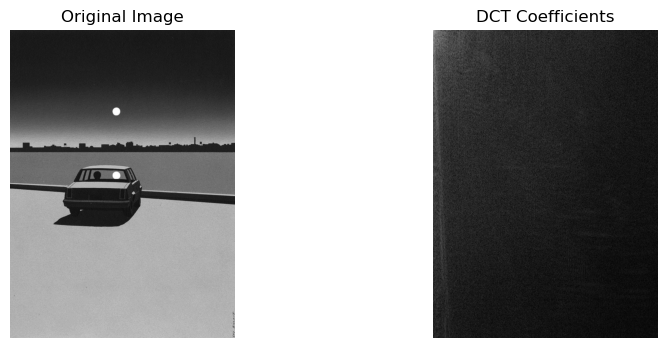

In [14]:
img_float = img1.astype(np.float32)
dct_coeff = cv2.dct(img_float)
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img1, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(np.log(1 + np.abs(dct_coeff)), cmap='gray')
plt.title('DCT Coefficients')
plt.axis('off')

plt.show()

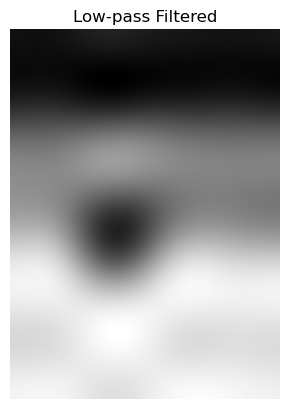

In [26]:
low_pass_dct = dct_coeff.copy()
cutoff = min(img1.shape) // 100
low_pass_dct[cutoff:, :] = 0
low_pass_dct[:, cutoff:] = 0
low_pass_img = cv2.idct(low_pass_dct)

plt.imshow(low_pass_img, cmap='gray')
plt.title('Low-pass Filtered')
plt.axis('off')
plt.show()

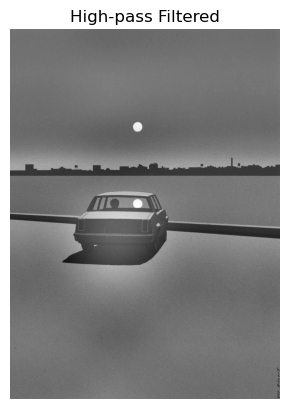

In [27]:
high_pass_dct = dct_coeff.copy()
high_pass_dct[:cutoff, :cutoff] = 0
high_pass_img = cv2.idct(high_pass_dct)

plt.imshow(high_pass_img, cmap='gray')
plt.title('High-pass Filtered')
plt.axis('off')
plt.show()

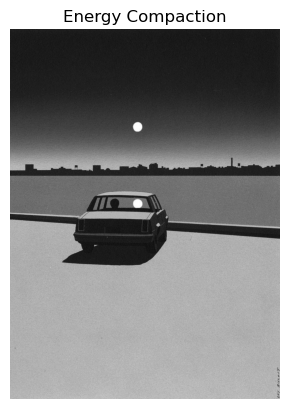

In [31]:
energy_dct = dct_coeff.copy()
threshold = np.percentile(np.abs(dct_coeff.flatten()), 1) 
energy_dct[np.abs(energy_dct) < threshold] = 0
energy_img = cv2.idct(energy_dct)

plt.imshow(energy_img, cmap='gray')
plt.title('Energy Compaction')
plt.axis('off')
plt.show()

In [14]:
import numpy as np
import cv2

# x(m,n) - the 4x4 input matrix
x = np.array([
    [1, -1, 3, 2],
    [2, 1, 2, 4],
    [1, -1, 2, -2],
    [3, 1, 2, 2]
])

# h(m,n) - the 3x3 kernel
h = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

# Expected result
y_expected = np.array([
    [2, -9, 9, -1],
    [5, 3, 0, 14],
    [0, -10, 9, -16],
    [7, 0, 3, 6]
])

print("Original x (4x4):")
print(x)
print("\nOriginal h (3x3):")
print(h)

# Augment size to 8x8
M, N = 8, 8

# Step 1: Apply border replication to x (extend borders before zero padding)
x_border = cv2.copyMakeBorder(x, 1, 1, 1, 1, cv2.BORDER_REPLICATE)
print("\nx with border replication (6x6):")
print(x_border)

# Step 2: Zero pad x to 8x8
x_padded = np.zeros((M, N), dtype=np.float32)
x_padded[0:x_border.shape[0], 0:x_border.shape[1]] = x_border
print("\nx with zero padding to 8x8:")
print(x_padded)

# Step 3: Zero pad h to 8x8
h_padded = np.zeros((M, N), dtype=np.float32)
h_padded[0:3, 0:3] = h
print("\nh with zero padding to 8x8:")
print(h_padded)

# Step 4: Apply circular shift to center the kernel
h_shifted = np.roll(h_padded, -1, axis=0)  # Shift up by 1
h_shifted = np.roll(h_shifted, -1, axis=1)  # Shift left by 1
print("\nh after circular shift:")
print(h_shifted)

# Step 5: Compute DFT of both matrices
dft_x = cv2.dft(x_padded, flags=cv2.DFT_COMPLEX_OUTPUT)
dft_h = cv2.dft(h_shifted, flags=cv2.DFT_COMPLEX_OUTPUT)
print(dft_h)
# Step 6: Multiply in frequency domain
dft_y = dft_x * dft_h

# Step 7: Inverse DFT
y_padded = cv2.idft(dft_y, flags=cv2.DFT_SCALE | cv2.DFT_REAL_OUTPUT)

print("\nFull convolution result (8x8):")
print(y_padded)

# Step 8: Extract the valid 4x4 region (central part for 'same' convolution)
y_result = y_padded[2:6, 2:6]  # Extract center 4x4 region

print("\nFinal result y (4x4):")
print(y_result)
print("\nExpected result:")
print(y_expected)
print("\nDifference:")
print(y_expected - y_result)

# Round to integers for exact comparison
y_result_rounded = np.round(y_result).astype(int)
print("\nRounded result:")
print(y_result_rounded)
print("\nExact match with expected:", np.array_equal(y_expected, y_result_rounded))

Original x (4x4):
[[ 1 -1  3  2]
 [ 2  1  2  4]
 [ 1 -1  2 -2]
 [ 3  1  2  2]]

Original h (3x3):
[[ 0 -1  0]
 [-1  5 -1]
 [ 0 -1  0]]

x with border replication (6x6):
[[ 1  1 -1  3  2  2]
 [ 1  1 -1  3  2  2]
 [ 2  2  1  2  4  4]
 [ 1  1 -1  2 -2 -2]
 [ 3  3  1  2  2  2]
 [ 3  3  1  2  2  2]]

x with zero padding to 8x8:
[[ 1.  1. -1.  3.  2.  2.  0.  0.]
 [ 1.  1. -1.  3.  2.  2.  0.  0.]
 [ 2.  2.  1.  2.  4.  4.  0.  0.]
 [ 1.  1. -1.  2. -2. -2.  0.  0.]
 [ 3.  3.  1.  2.  2.  2.  0.  0.]
 [ 3.  3.  1.  2.  2.  2.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.]]

h with zero padding to 8x8:
[[ 0. -1.  0.  0.  0.  0.  0.  0.]
 [-1.  5. -1.  0.  0.  0.  0.  0.]
 [ 0. -1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.]]

h after circular shift:
[[ 5. -1.  0.  0.  0.  0.  0. -1.]
 [-1.  0.  0.  0.  0.  0